<font face="B Mitra" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=6>
<b>پروژه سوم داده کاوی</b>
<br>
<b><font size=5> استاد درس: دکتر فاطمه شاکری</b>
<hr>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=5>
کتابخانه های موردنیاز را در این بخش بارگذاری کنید.
</p>
</font>
</div>
</font>

In [ ]:
!pip install langdetect
!pip install scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_lg-0.5.4.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=31ec1fd12f7b4f9a35b5270578210c821387b16655fe60656cbc7bb0a7d215a9
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 36.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 kB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 7.8 MB/s eta 0:00:00
  Using cached pybind11-2.6.1-py2.py3-none-any.whl (188 kB)
  Created wheel for nmslib: filename=nmslib-2.1.1-cp310-cp310-linux_x86_64.whl size=13578645 sha256=6bf185c5c923873e10d7a597078881242d405ce42fb133311618175a

<font face="B Mitra">
<div dir=rtl>
<font size=5>
نصب پکیج <code>spacy</code> ممکن است وابسته به سیستم‌عامل و پکیج‌منیجر شما نیاز به دستوری متفاوت داشته‌باشد. دستور مناسب را می‌تواند با استفاده از
<a href="https://spacy.io/usage">این لینک</a> بیابید.
</p>
</font>
</div>
</font>

In [ ]:

import numpy as np
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%config InlineBackend.figure_formats = ['svg']
import seaborn as sns

# Used to draw a progress bar for longer method calls
from tqdm import tqdm

# Used to detect language used in each document
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 0

# Pre-trained natural language processing pipeline for biomedical use
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import en_core_sci_lg

# Used to import list of punctuations
import string

# Feature extraction (text vectorizers)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering and evaluation
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> لود کردن مجموعه داده </b>
<br>
<p align="justify">
<font size=5>
فایل مجموعه داده در <a href="https://drive.google.com/file/d/15E8FLX0C-6qpK-lDBEQJXw00Lsdcvjae/view?usp=sharing">گوگل درایو</a> در اختیار شما قرار گرفته است:
<br>
همچنین در صورت استفاده از گوگل کولب با استفاده از دستور زیر میتوانید مجموعه داده را از گوگل درایو در نوتبوک خود دانلود کنید.
</p>
</font>
</div>
</font>

!gdown 15E8FLX0C-6qpK-lDBEQJXw00Lsdcvjae

<font face="B Mitra">
<div dir=rtl>
<font size=5>
در شروع کار،دیتافریم موردنظر خود را ایجاد کردیم و مقادیر خالی را با space جایگزین کردیم.
دلیل این کار جلوگیری از خطا در مصورسازی انتهایی است.<br>
سپس با توجه به زمانبر بودن اجرا،حداقل یک سمپل 1500 تایی نمونه برداری کردیم.
<br>
برای کسب نتایج بهتر و مصورسازی مناسبتر میتوانیم تعداد سمپل را افزایش دهیم.
</p>
</font>
</div>

In [ ]:
!gdown 15E8FLX0C-6qpK-lDBEQJXw00Lsdcvjae

Downloading...
From (original): https://drive.google.com/uc?id=15E8FLX0C-6qpK-lDBEQJXw00Lsdcvjae
From (redirected): https://drive.google.com/uc?id=15E8FLX0C-6qpK-lDBEQJXw00Lsdcvjae&confirm=t&uuid=e9d4f90d-5257-4c15-b426-f750a5421589
To: /content/10k_df.csv
100% 341M/341M [00:04<00:00, 70.7MB/s]


In [ ]:
df_10k = pd.read_csv('10k_df.csv')

In [ ]:
df_10k.shape

(10000, 8)

In [ ]:
df_10k.head(5)

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary
0,d2552c4941d8e1e349686d7ec0d0b427ecb3ac3d,10.1007/978-1-4939-3414-0_2,"Porcine epidemic diarrhea virus (PEDV), a memb...","2013 to present, has led to a substantial loss...","Jung, Kwonil",Immunohistochemical Staining for Detection<br...,Animal Coronaviruses,"Porcine epidemic diarrhea virus (PEDV), a<br>..."
1,b52acf51745c0b6aacd9020e2e86f114b4d1ee72,10.1016/j.orgdyn.2020.100765,Page 2 of 23 J o u r n a l P r e -p r o o f 2 ...,"4 making, and empathy. It is not a stretch to ...","Seijts, Gerard. Milani, Kimberley Young",The Myriad Ways in Which COVID-19 Revealed<br...,Organ Dyn,Page 2 of 23 J o u r n a l P r e -p r o o f 2...
2,ad64637f84246d552d9d2cc5b13d66a51f8cc7bf,10.1016/j.puhe.2005.10.002,Severe Acute Respiratory Syndrome (SARS) emerg...,Severe acute respiratory syndrome (SARS) has e...,"Shaw, Karen",The 2003 SARS outbreak and its impact on<br>i...,Public Health,Severe Acute Respiratory Syndrome (SARS)<br>e...
3,30c832e81049d050f9f0c0b4887d0008d86ebc7c,10.12659/msm.889695,In 2005 we published the first study to show t...,In 2005 we published the first study to show t...,"Puliyel, Jacob",Prone to survive and the priority rule in<br>...,Med Sci Monit,In 2005 we published the first study to show ...
4,5c0a8915074d15c38dd14f76ccf9a1d0d78278f5,10.1007/bf02878241,NaN,"Scanning electron microscopy, X-ray miereanaly...","Ludvík, J.. Beneš, K.. Tupý, J.. Slavík, J...",Book reviews,Biol,Not provided.


In [ ]:
df_10k.fillna(value=" ",inplace=True)

In [ ]:
df = df_10k.sample(1500, random_state=42)
del df_10k

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> پیش پردازش متن</b>
<br>
<p align="justify">
<font size=5>
 برای پیش پردازش متون از کتابخانه های مختلفی از جمله NLTK ،Gensim یا Spacy میتوان استفاده کرد.
 <br>
 مواردی که در پیش پردازش متون باید به آن توجه کرد.
 <ol>
 <br>
 <li> <b>تشخیص زبان مورداستفاده مقاله ها:</b>
  در این مجموعه داده میتوانید  با استفاده از کتابخانه langdetect زبان مورد استفاده مقاله را در ویژگی <code>body_text</code> بررسی کنید.
 با توجه به نتیجه نهایی خواهید دید که زبان انگلیسی زبان غالب در این مقاله هاست بنابراین میتوان مقاله های غیر انگلیسی را حذف کرد.
 </li>
 <li> <b>توکنایز کردن (Tokenize) مدل ها:</b>
 در این مجموعه داده از  پایپ لاین  <code>en_core_sci_lg</code> از کتابخانه  spaCy به دلیلی پشتبانی از داده های زیستی و پزشکی و با بردارهای 600 هزار کلمه ای و واژگان بزرگتر میتوانیم استفاده کنیم.<br>
 به دلیل اینکه SpaCy حداکثر یک میلیون کاراکتر را بررسی میکند میتوان با استفاده از max_length این محدودیت را کاهش داد:
 لطفا از parser مشخص شده در بخش زیر برای توکنایز کردن متن خود استفاده کنید.


 </li>
 <li> <b> Lemmatization یا Stemming (ریشه یابی) </b>
 </li>
 <li> <b>حذف Stopwords</b> </li>
 <li> <b>حذف علائم نشانه گذاری</b> </li>
 </ol>
<br>
درمورد هر یک از موارد بالا جستجو کنید و پیش پردازش های لازم را برای ویژگی "body text" مقاله انجام دهید.
</p>
</font>
</div>
</font>

In [ ]:
def detect_language(text):
  try:
    return detect(text)
  except:
    return "Unknown"


df['language'] = df['body_text'].apply(detect_language)

df['language'].value_counts()

language
en    1454
de      25
fr       8
es       8
it       2
nl       2
pt       1
Name: count, dtype: int64

In [ ]:
# Removing articles that are not in English
df = df[df['language'] == 'en']

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
مقاله‌های غیر انگلیسی را حذف کردیم.

</p>
</font>
</div>
</font>

In [ ]:
# Parser
parser = en_core_sci_lg.load(disable=["tagger", "ner"])
parser.max_length = 3000000


def tokenize_text(text):
  doc = parser(text)
  tokens = [token.text.lower() for token in doc if token.is_alpha and token.text not in STOP_WORDS]
  return tokens


df['body_tokens'] = df['body_text'].apply(tokenize_text)

/usr/local/lib/python3.10/dist-packages/spacy/pipeline/lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [ ]:
df.head(5)

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,body_tokens
6252,fefd6cdcddcb00d1ba2ef1a0d3bba9f312010a1d,10.1111/j.1524-4733.2008.00379.x,,China is the biggest country in the world that...,"Li, Youing. Sun, Xin. Wang, Li",Evidence-Based Medicine in China,Value in Health,Not provided.,en,"[china, biggest, country, world, billion, popu..."
4684,2a3d080d5dcf6771db002366691f35e5d6f0e493,10.1007/s13238-010-0029-7,,"✉ Correspondence: zlshi@wh.iov.cn Bat, the onl...","Shi, Zhengli",Bat and virus,Protein & Cell,Not provided.,en,"[correspondence, bat, flying, mammal, count, e..."
1731,2de657aabab331e75657bfc1443542fd345b6f26,10.1016/j.ccc.2019.06.001,KEYWORDS\nPandemic Influenza Disaster prepared...,Outbreaks of infectious disease pose unique ch...,"Maves, Ryan C.. Jamros, Christina M.. Smith...",Intensive Care Unit Preparedness During<br>Pa...,Crit Care Clin,KEYWORDS\nPandemic Influenza Disaster<br>prep...,en,"[outbreaks, infectious, disease, pose, unique,..."
4742,bc22758234283f024f16e2dbe660bc909b512b92,10.1016/j.vetpar.2007.11.020,Cryptosporidium parvum is recognized as one of...,Diarrhoeal diseases of infectious aethiology r...,"Klein, Pavel. Kleinová, Tereza. Volek,<br>Z...",Effect of Cryptosporidium parvum infection on...,Veterinary Parasitology,Cryptosporidium parvum is recognized as one o...,en,"[diarrhoeal, diseases, infectious, aethiology,..."
4521,a204aafa38365dbcc0a26af3ca2c6d3313d7fab2,10.1111/irv.12518,", Brazil, in the period of Background: The res...",The inclusion criteria for asymptomatic adults...,"Moreira, Luciana Peniche. Watanabe, Aripuana...",Respiratory syncytial virus evaluation among<...,Influenza Other Respir Viruses,", Brazil, in the period of Background: The<br...",en,"[the, inclusion, criteria, asymptomatic, adult..."


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
Tokenization در حوزه پردازش زبان طبیعی (NLP)، به فرآیند تبدیل یک متن به بخش‌های کوچک‌تر، معروف به توکن، اشاره دارد.
<br>
اهمیت این فرآیند این است که به ماشین‌ها کمک می‌کند زبان انسان را با شکستن آن به قطعات کوچک‌تر درک کنند و آسانتر بتوانند آن را تجزیه و تحلیل کنند.
<br>
یکی از دلایل اصلی توکن‌سازی تبدیل داده‌های متنی به یک نمایش عددی است که می‌تواند توسط الگوریتم های یادگیری ماشین پردازش شود. با این نمایش عددی می‌توانیم مدل را برای انجام وظایف مختلف مانند طبقه‌بندی، تحلیل احساسات یا تولید زبان آموزش دهیم.
<br><br>
«دقت شود که در همین مرحله حذف Stopwords نیز اتفاق می‌افتد.»

</p>
</font>
</div>
</font>

In [ ]:
def remove_punctuation(text):
  filtered_words = [word for word in text if word not in string.punctuation]
  return filtered_words

# Apply the remove_punctuation function to the 'body_tokens' column
df['body_no_punctuation'] = df['body_tokens'].apply(remove_punctuation)

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در این قسمت علائم نشانه‌گذاری را حذف کردیم.

</p>
</font>
</div>
</font>

In [ ]:
from nltk.stem import PorterStemmer

# Create a PorterStemmer object
stemmer = PorterStemmer()

def stem_text(text):
  stems = [stemmer.stem(token) for token in text]
  return stems

df['body_stems'] = df['body_no_punctuation'].apply(stem_text)

In [ ]:
df.head(5)

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,body_tokens,body_no_punctuation,body_stems
6252,fefd6cdcddcb00d1ba2ef1a0d3bba9f312010a1d,10.1111/j.1524-4733.2008.00379.x,,China is the biggest country in the world that...,"Li, Youing. Sun, Xin. Wang, Li",Evidence-Based Medicine in China,Value in Health,Not provided.,en,"[china, biggest, country, world, billion, popu...","[china, biggest, country, world, billion, popu...","[china, biggest, countri, world, billion, popu..."
4684,2a3d080d5dcf6771db002366691f35e5d6f0e493,10.1007/s13238-010-0029-7,,"✉ Correspondence: zlshi@wh.iov.cn Bat, the onl...","Shi, Zhengli",Bat and virus,Protein & Cell,Not provided.,en,"[correspondence, bat, flying, mammal, count, e...","[correspondence, bat, flying, mammal, count, e...","[correspond, bat, fli, mammal, count, extant, ..."
1731,2de657aabab331e75657bfc1443542fd345b6f26,10.1016/j.ccc.2019.06.001,KEYWORDS\nPandemic Influenza Disaster prepared...,Outbreaks of infectious disease pose unique ch...,"Maves, Ryan C.. Jamros, Christina M.. Smith...",Intensive Care Unit Preparedness During<br>Pa...,Crit Care Clin,KEYWORDS\nPandemic Influenza Disaster<br>prep...,en,"[outbreaks, infectious, disease, pose, unique,...","[outbreaks, infectious, disease, pose, unique,...","[outbreak, infecti, diseas, pose, uniqu, chall..."
4742,bc22758234283f024f16e2dbe660bc909b512b92,10.1016/j.vetpar.2007.11.020,Cryptosporidium parvum is recognized as one of...,Diarrhoeal diseases of infectious aethiology r...,"Klein, Pavel. Kleinová, Tereza. Volek,<br>Z...",Effect of Cryptosporidium parvum infection on...,Veterinary Parasitology,Cryptosporidium parvum is recognized as one o...,en,"[diarrhoeal, diseases, infectious, aethiology,...","[diarrhoeal, diseases, infectious, aethiology,...","[diarrhoeal, diseas, infecti, aethiolog, repre..."
4521,a204aafa38365dbcc0a26af3ca2c6d3313d7fab2,10.1111/irv.12518,", Brazil, in the period of Background: The res...",The inclusion criteria for asymptomatic adults...,"Moreira, Luciana Peniche. Watanabe, Aripuana...",Respiratory syncytial virus evaluation among<...,Influenza Other Respir Viruses,", Brazil, in the period of Background: The<br...",en,"[the, inclusion, criteria, asymptomatic, adult...","[the, inclusion, criteria, asymptomatic, adult...","[the, inclus, criteria, asymptomat, adult, abs..."


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
Stemming و Lemmatization تکنیک‌های پیش پردازش متن در NLP هستند.
آنها اشکال عطف کلمات را در یک مجموعه داده متنی به یک کلمه ریشه مشترک کاهش می دهند.
<br>
برای مثال تمام کلمات {Dancing,  Danced,  Dancer,  Dances} به کلمه "Dance" تغییر می‌یابند.
<br>
روش Lemmatization، متن زمینه را در نظر می‌گیرد و کلمه را به شکل پایه معنی دار خود تبدیل می‌کند که به آن Lemma می گویند.
در حالی که روش Stemming چند کاراکتر آخر یک کلمه را حذف می‌کند که اغلب منجر به معانی و املای نادرست می‌شود.
<br>
Lemmatization از نظر محاسباتی گرانتر است زیرا شامل جداول جستجو و موارد دیگر می‌شود.
در نتیجه برای مجموعه داده‌های بزرگ از روش Stemming استفاده می‌شود.


</p>
</font>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> ذخیره تغییرات در فایل df_preprocessed.csv </b>
<p align="justify">
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
پس از انجام مرحله پیش پردازش، بدلیل زمان‌گیر بودن اجرای این مرحله، فایل نهایی را ذخیره می‌کنیم
تا هنگام انجام ادامه پروژه در زمانمان صرفه‌جویی شود.


</p>
</font>
</div>
</font>

In [ ]:
!gdown 1XUOWIuX8ek-Dh5I3hkxTeVRN_UGAG2wR

Downloading...
From (original): https://drive.google.com/uc?id=1XUOWIuX8ek-Dh5I3hkxTeVRN_UGAG2wR
From (redirected): https://drive.google.com/uc?id=1XUOWIuX8ek-Dh5I3hkxTeVRN_UGAG2wR&confirm=t&uuid=672c9648-abdc-478a-ad37-f0907211a8c8
To: /content/df_preprocessed.csv
100% 184M/184M [00:01<00:00, 149MB/s]


In [ ]:
df_preprocessed = pd.read_csv('df_preprocessed.csv')

df_preprocessed.head(5)

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,body_tokens,body_no_punctuation,body_stems
0,fefd6cdcddcb00d1ba2ef1a0d3bba9f312010a1d,10.1111/j.1524-4733.2008.00379.x,,China is the biggest country in the world that...,"Li, Youing. Sun, Xin. Wang, Li",Evidence-Based Medicine in China,Value in Health,Not provided.,en,"['china', 'biggest', 'country', 'world', 'bill...","['china', 'biggest', 'country', 'world', 'bill...","['china', 'biggest', 'countri', 'world', 'bill..."
1,2a3d080d5dcf6771db002366691f35e5d6f0e493,10.1007/s13238-010-0029-7,,"✉ Correspondence: zlshi@wh.iov.cn Bat, the onl...","Shi, Zhengli",Bat and virus,Protein & Cell,Not provided.,en,"['correspondence', 'bat', 'flying', 'mammal', ...","['correspondence', 'bat', 'flying', 'mammal', ...","['correspond', 'bat', 'fli', 'mammal', 'count'..."
2,2de657aabab331e75657bfc1443542fd345b6f26,10.1016/j.ccc.2019.06.001,KEYWORDS\nPandemic Influenza Disaster prepared...,Outbreaks of infectious disease pose unique ch...,"Maves, Ryan C.. Jamros, Christina M.. Smith...",Intensive Care Unit Preparedness During<br>Pa...,Crit Care Clin,KEYWORDS\nPandemic Influenza Disaster<br>prep...,en,"['outbreaks', 'infectious', 'disease', 'pose',...","['outbreaks', 'infectious', 'disease', 'pose',...","['outbreak', 'infecti', 'diseas', 'pose', 'uni..."
3,bc22758234283f024f16e2dbe660bc909b512b92,10.1016/j.vetpar.2007.11.020,Cryptosporidium parvum is recognized as one of...,Diarrhoeal diseases of infectious aethiology r...,"Klein, Pavel. Kleinová, Tereza. Volek,<br>Z...",Effect of Cryptosporidium parvum infection on...,Veterinary Parasitology,Cryptosporidium parvum is recognized as one o...,en,"['diarrhoeal', 'diseases', 'infectious', 'aeth...","['diarrhoeal', 'diseases', 'infectious', 'aeth...","['diarrhoeal', 'diseas', 'infecti', 'aethiolog..."
4,a204aafa38365dbcc0a26af3ca2c6d3313d7fab2,10.1111/irv.12518,", Brazil, in the period of Background: The res...",The inclusion criteria for asymptomatic adults...,"Moreira, Luciana Peniche. Watanabe, Aripuana...",Respiratory syncytial virus evaluation among<...,Influenza Other Respir Viruses,", Brazil, in the period of Background: The<br...",en,"['the', 'inclusion', 'criteria', 'asymptomatic...","['the', 'inclusion', 'criteria', 'asymptomatic...","['the', 'inclus', 'criteria', 'asymptomat', 'a..."


<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> استخراج ویژگی </b>
<br>
<p align="justify">
<font size=5>
اکنون که متن بدنهٔ مقاله‌ها را از قبل پردازش کرده‌ایم، زمان تبدیل آن‌ها به قالبی است که توسط الگوریتم‌های ما قابل استفاده باشد. برای این منظور از tf-idf استفاده خواهیم کرد. tf_idf  یک الگوریتم بسیار رایج برای تبدیل متن به نمایش معنی دار اعداد است که اهمیت هر کلمه را در متن موردنظر نشان میدهد. <br>
درمورد عملکرد این روش جستجو کنید.
 برای متن پیش پردازش شده هر مقاله، با استفاده از این روش یک بازنمایی برداری با حداکثر 4096 ویژگی ایجاد کنید.
</p>
</font>
</div>
</font>

In [ ]:
vectorizer = TfidfVectorizer(max_features=4096)

count_matrix = vectorizer.fit_transform(df_preprocessed['body_stems'])

feature_names = vectorizer.get_feature_names_out()

print(count_matrix.shape)

(1454, 4096)


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
TF-IDF (term frequency-inverse document frequency) یک معیار آماری است که میزان ارتباط یک کلمه را با یک سند در مجموعه ای از اسناد ارزیابی می‌کند.
<br><br>
TF (Term Frequency) : فراوانی کلمه t را در سند d نمایش می‌دهد.
<br>
tf(t,d) = count of t in d / number of words in d
<br><br>
IDF (Inverse Document Frequency) : لگاریتم معکوس فراوانی تعداد اسنادی که شامل کلمه t هستند را نمایش می‌دهد.
<br>
df(t) = log(inverse of the frequency of documents that contain t)
<br><br>
ضرب این دو عدد منجر به امتیاز TF-IDF یک کلمه در یک سند می‌شود. هرچه امتیاز بالاتر باشد، آن کلمه به آن سند ارتباط بیشتری دارد.


</p>
</font>
</div>
</font>

In [ ]:
count_array = count_matrix.toarray()

type(count_array)

numpy.ndarray

In [ ]:
df_array = pd.DataFrame(count_array, columns=feature_names)

df_array.head(5)

,aa,ab,abdomen,abdomin,aberr,abil,abl,ablat,abnorm,abolish,...,zikv,zinc,zone,zoonot,µg,µl,µm,μg,μl,μm
0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.005349,0.000000,0.0,0.0,0.011075,...,0.0,0.0,0.0,0.019255,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.013182,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.011862,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.012123,0.0,0.0,0.0,0.0,0.000000,0.005668,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.010163,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.023584,0.0


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
خروجی فرایند tf-idf، یک Sparse Matrix است. ابتدا این ماتریس را به یک numpy array تبدیل می‌کنیم.
سپس آرایه را به یک مجموعه داده تبدیل می‌کنیم.


</p>
</font>
</div>
</font>

<font face="B Mitra"><div dir=rtl>
<font size=6>
<b> PCA </b>
<br>
<p align="justify">
<font size=5>
با توجه به ابعاد بالای هر بردار ویژگی، با استفاده از روش PCA با حفظ 95 درصد واریانس کاهش بعد دهید.
</p>
</font>
</div>

In [ ]:
# Define the PCA object with the 95% variance ratio
pca = PCA(n_components=0.95)

df_tfidf_dimreduced = pca.fit_transform(df_array)

In [ ]:
df_tfidf_dimreduced = pd.DataFrame(df_tfidf_dimreduced)

df_tfidf_dimreduced.head(5)

,0,1,2,3,4,5,6,7,8,9,...,957,958,959,960,961,962,963,964,965,966
0,-0.157235,0.134518,-0.150002,-0.133960,0.040336,0.012515,-0.105962,-0.190301,0.041164,0.029435,...,-0.017579,0.026557,-0.010910,0.010295,-0.005704,-0.010963,-0.021426,0.002677,0.043785,0.003715
1,0.114976,0.101125,-0.125781,0.198691,0.087667,0.237775,0.057186,0.064866,0.182230,0.040070,...,0.007945,-0.009480,0.008493,-0.005240,-0.000078,0.005373,0.002160,-0.008025,-0.006158,0.001875
2,-0.374954,-0.103166,-0.124996,-0.077225,0.096953,0.089604,-0.187138,-0.152729,-0.088854,-0.035151,...,0.008758,0.020945,-0.011666,-0.009682,0.011069,0.012793,0.000879,0.002237,-0.000272,-0.009270
3,0.010517,0.010197,-0.019434,0.034904,-0.005171,-0.056386,0.202135,-0.006998,0.035882,-0.084269,...,0.007986,0.012238,-0.026486,-0.019673,-0.021649,0.013050,-0.007055,-0.001542,0.006685,-0.000076
4,-0.109142,-0.088755,-0.007149,0.177122,0.079825,-0.134609,0.069173,0.049561,-0.082731,0.219225,...,-0.002606,0.019484,0.001522,-0.024870,0.006110,-0.005719,-0.004794,0.000496,-0.008456,0.001844


<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> خوشه بندی </b>
<br>
<p align="justify">
<font size=5>
خوشه بندی مقالات تحقیقاتی مشابه با هم می تواند جستجوی انتشارات مرتبط را ساده کند.  در اینجا از روش K-Means برای خوشه بندی استفاده میکنیم.<br>
 با استفاده از روش Elbow Method  از بین تعداد خوشه های داده شده، میتوانید بهترین تعداد خوشه را بیابید.
<br>
تا 30 خوشه این موضوع را مورد بررسی قرار دهید و پس از یافتن تعداد خوشه مناسب، با استفاده از روش K-Means خوشه بندی لازم را برای بردار ویژگی
بدست آماده از مرحلهٔ قبل به کار بگیرید.
<br><b> بخش امتیازی:</b> میتوانید با به کارگیری روش های دیگر خوشه بندی نظیر خوشه بندی سلسه مراتبی یا DBSCAN نتایج را با استفاده از یک معیار ارزیابی مناسب  مقایسه کنید.
</p>
</font>
</div>

In [ ]:
k_range = range(2, 61, 3)
wcss_list = []

for k in k_range:
  # Perform K-Means clustering
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(df_tfidf_dimreduced)

  wcss = kmeans.inertia_
  wcss_list.append(wcss)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

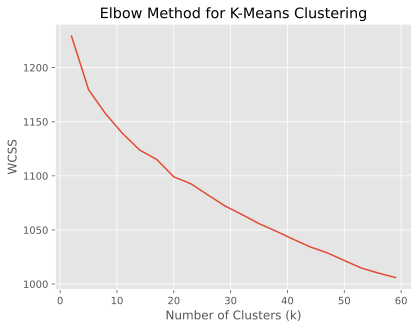

In [ ]:
# Elbow method graph
plt.plot(k_range, wcss_list)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<br>
<p align="justify">
<font size=5>
با توجه به اینکه قرار بود از روش elbow استفاده کنیم و طبق مشاهدات ما در داده‌های واقعی elbow به صورت واضح مشخص نیست، ما k را عدد ۵ تشخیص داده‌ایم.
</p>
</font>
</div>

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> t-SNE </b>
<br>
<p align="justify">
<font size=5>
t_SNE یک روش نظارت نشده غیر خطی است که برای اکتشاف و بصری‌سازی داده‌ها مورد استفاده قرار می‌گیرد.
PCA یک روش کاهش ابعاد خطی است که در تلاش برای بیشینه کردن واریانس و حفظ فاصله‌های زیاد دوتایی‌ها از یکدیگر است. این امر می‌تواند منجر به بصری‌سازی ضعیف به ویژه هنگام کار با ساختارهای غیرخطی می‌شود. t-SNE  با حفظ فاصله‌های کم دوتایی‌ها یا شباهت محلی از PCA متمایز می‌شود. به بیان ساده‌تر، t-SNE به کاربر درکی از اینکه داده‌ها چگونه در فضای ابعاد بالا سازمان‌دهی شده‌اند را ارائه می‌کند. <br>
با استفاده از t-SNE می توانیم بردار ویژگی هایی با ابعاد بالا را به 2 بعد کاهش دهیم.
در این مجموعه داده در 2 بعد می توان توزیع مقالات را با استفاده از scatterplot نمایش داد. <br>
برای تفکیک بصری موضوعات مختلف در نمودار بالا، با استفاده از خوشه هایی که در KMeans یافتید ، برای رنگ آمیزی خوشه های مختلف در مصورسازی خود میتوانید استفاده کنید.
</p>
</font>
</div>

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


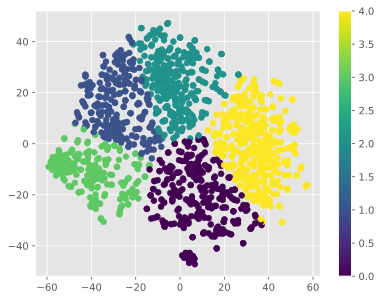

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X_embedded = TSNE(n_components=2).fit_transform(count_array)

kmeans = KMeans(n_clusters=5)
kmeans.fit(X_embedded)
y_kmeans = kmeans.predict(X_embedded)

plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_kmeans, cmap='viridis')
plt.colorbar()
plt.show()

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ابتدا برای راحتی نمایش داده ها در نمودار پراکندگی با استفاده از TSNE بعد داده‌ها را به فضای دو بعدی کاهش میدهیم.
<br>
سپس با یک خوشه‌بند kmeans با ۵ خوشه (عدد ۵ در بخش قبل به دست آمد) خوشه بندی را انجام میدهیم.
سپس این مدل را روی داده های embeded ترین میکنیم.
در آخر داده‌های مربوط به هر خوشه را با رنگی مجزا نمایش می‌دهیم.


</p>
</font>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> مدلسازی موضوعی (Topic Modeling)</b>
<br>
<p align="justify">
<font size=5>
اکنون سعی خواهیم کرد موضوعات کلیدی در هر خوشه را پیدا کنیم.
<br>
 K-means مقالات را خوشه بندی کرد اما موضوعات را برچسب گذاری نکرد. از طریق مدل‌سازی موضوع، متوجه خواهیم شد که مهمترین اصطلاحات برای هر خوشه چیست. این کار با دادن کلمات کلیدی برای شناسایی سریع مضامین خوشه، معنای بیشتری به خوشه می بخشد.<br>
برای مدلسازی موضوعی از الگوریتم های مختلفی نظیر NMF,LSA,LDA میتوان استفاده کرد.
<br>
تعداد موضوعاتی که از خوشه ها قصد دارید استخراج کنید، را به دلخواه انتخاب کنید.
<br>
با استفاده از روش (Latent Dirichlet allocation)LDA موضوعات مناسب را به تعداد موردنظر برای هر خوشه بیابید.
سپس کلمات کلیدی هر موضوع برای خوشه موردنظر را چاپ کنید.
<br><b> بخش امتیازی:</b> مدلسازی موضوعی با روشی غیر از LDA انجام دهید و موضوعات خوشه ها را در هردو روش با هم مقایسه کنید.

</p>
</font>
</div>

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Convert the reduced array to non-negative values
min_val = np.min(count_array)
if min_val < 0:
    count_array += np.abs(min_val)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(count_array)

# Get the topic-word distribution
topic_word_distributions = lda.components_

# Print the key words for each topic in each cluster
n_top_words = 5
feature_names = np.array(feature_names)
for cluster_idx, cluster in enumerate(topic_word_distributions):
    top_words_idx = cluster.argsort()[:-n_top_words-1:-1]
    top_words = feature_names[top_words_idx]
    print(f"Cluster {cluster_idx+1}: {', '.join(top_words)}")

Cluster 1: patient, the, infect, studi, diseas
Cluster 2: exosom, sot, dmi, hiltonol, cbx
Cluster 3: mnnlp, hape, pdd, balt, sox
Cluster 4: cell, protein, et, the, preprint
Cluster 5: sequenc, protein, bat, genom, structur


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ابتدا مطمئن میشویم همه داده‌ها نامنفی باشند. سپس مدل lda را با ۵ component و با استفاده از عدد تصادفی ۴۲ ایجاد میکنیم. این عدد تصادفی برای کاهش رندوم بودن داده‌ها و ثبات نتایج است.
حالا مدل را با استفاده از داده‌های reduced_array ترین میکنیم. در آخر ماتریس topic word را از مدل ترین شده‌ی lda استخراج میکنیم.  
این ماتریس احتمالات مربوط به هر کلمه را برای هر موضوع نشان می دهد.
در آخر کد ۵ کلمه با بالاترین احتمال برای موضوع را پیدا میکند.
از feature_names برای یافتن کلمات واقعی مربوط به آن شاخص ها استفاده می شود.
شماره خوشه و لیست کلمات کلیدی آن موضوع  چاپ می شود.
هدف این کد، شناسایی و دسته‌بندی موضوعات موجود در مجموعه داده ها و همچنین مرتبط کردن هر موضوع با کلمات کلیدی مرتبط است.


</p>
</font>
</div>
</font>

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Convert the reduced array to non-negative values
min_val = np.min(count_array)
if min_val < 0:
    count_array += np.abs(min_val)

lsa = TruncatedSVD(n_components=5, random_state=42)
lsa.fit(count_array)

# Print top words for each cluster
for cluster_idx, cluster in enumerate(lsa.components_):
    top_words_idx = cluster.argsort()[:-n_top_words-1:-1]
    top_words = feature_names[top_words_idx]
    print(f"Cluster {cluster_idx+1}: {', '.join(top_words)}")

Cluster 1: the, patient, cell, infect, et
Cluster 2: cell, protein, et, sequenc, express
Cluster 3: preprint, medrxiv, licens, model, copyright
Cluster 4: preprint, medrxiv, licens, cell, copyright
Cluster 5: sequenc, sampl, et, detect, pcr


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
خروجی LDA:
<br>
خروجی LDA لیستی از کلمات کلیدی با بیشترین وزن برای هر خوشه (Cluster) است. (مثال: خوشه 1: patient, infect, و غیره)
این کلمات نشان دهنده محتوای اصلی اسناد یا داده های متعلق به آن خوشه هستند.
<br><br>
خروجی LSA:
<br>
خروجی LSA لیستی از مولفه های اصلی (Components) برای هر خوشه است. (مثال: خوشه 1: patient, cell, و غیره)
این مولفه ها جهت های اصلی در فضای ویژگی ها را نشان می دهند که خوشه را تعریف می کنند. 
<br><br>
در کل:
خروجی LDA برای درک موضوعات با کلمات کلیدی واضح تر است.
خروجی LSA ممکن است برای درک ساختار کلی روابط بین متون در یک خوشه مناسب تر باشد. 


</p>
</font>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b>  مصورسازی </b>
<br>
<p align="justify">
<font size=4>
<b>این بخش شامل نمره نیست و صرفا جهت درک شما از مراحل انجام شده است</b><br>
<font size=5>
مراحل قبلی برچسب‌های خوشه‌بندی و مجموعه‌ای از مقالات را به دو بعد کاهش داده است. می‌توانیم یک طرح تعاملی از خوشه ها ایجاد کنیم. <br>
شما میتوانید با انتخاب هر خوشه از اسلایدر، توزیع هر خوشه را به صورت مجزا مشاهده کنید. همچنین میتوانید با بردن نشانگر روی هریک از نقاط مشخصات کلی آن مقاله را مشاهده کنید.
<br>
<img src="https://drive.google.com/uc?id=14xXSuD-FhmSSJBI0oH-a-DDkgjBtqj4_" alt="Linear Algebra Cover Art" width="800">
</p>
</font>
</div>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ورودی تابع زیر، دیتافریم مقالات می‌باشد که می‌بایست شامل ستون‌های زیر باشد:
<br>
1. <code>tsne-2d-one</code>: مولفهٔ اول t-SNE
<br>
2. <code>tsne-2d-two</code>: مولفهٔ دوم t-SNE
<br>
3. <code>y</code>: خوشهٔ هر یک از مقالات
</p>
</font>
</div>

In [ ]:
def interactive_plot(df):
    clusters = sorted(df['y'].unique())

    # Generate distinct colors for each cluster using Plotly's colors
    colors = px.colors.qualitative.Plotly

    # Create a scatter plot for each cluster with a unique color
    data = []
    for i, cluster in enumerate(clusters):
        cluster_data = df[df['y'] == cluster]
        scatter = go.Scatter(
            x=cluster_data['tsne-2d-one'],
            y=cluster_data['tsne-2d-two'],
            mode='markers',
            name=f'Cluster {cluster}',
            text=cluster_data['title'],
            hoverinfo='text',
            marker=dict(size=10, color=colors[i % len(colors)]),
            visible=False
        )
        data.append(scatter)

    # Add a scatter plot for all clusters with different colors
    scatter_all = go.Scatter(
        x=df['tsne-2d-one'],
        y=df['tsne-2d-two'],
        mode='markers',
        name='All Clusters',
        text=df['title'],
        hoverinfo='text',
        marker=dict(size=10, color=df['y'].map(lambda x: colors[x % len(colors)])),  # Assign colors by cluster
        visible=True
    )
    data.append(scatter_all)

    x_min = df['tsne-2d-one'].min()
    x_max = df['tsne-2d-one'].max()
    y_min = df['tsne-2d-two'].min()
    y_max = df['tsne-2d-two'].max()

    fig = go.Figure(data=data)

    # Ensure square aspect ratio
    fig.update_layout(
        title='Cluster Visualization',
        xaxis=dict(title='t-SNE 1', range=[x_min, x_max]),
        yaxis=dict(title='t-SNE 2', range=[y_min, y_max]),
        width=1000,
        height=700
    )

    # Hover functionality
    fig.update_traces(
        hoverinfo='text',
        marker=dict(opacity=0.7, size=8),
    )

    # Interactive slider for cluster selection
    steps = []
    for i, cluster in enumerate(clusters):
        step = dict(
            method='update',
            args=[{'visible': [False] * len(clusters) + [False]},
                {'title': f'Cluster {cluster}'}],
            label=f'Cluster {cluster}'
        )
        # Only make the current cluster visible
        step['args'][0]['visible'][i] = True
        steps.append(step)

    # Add final step for all clusters
    steps.append(dict(
        method='update',
        args=[{'visible': [False] * len(clusters) + [True]},  # Only show the 'all clusters' trace
            {'title': 'All Clusters'}],
        label='All Clusters'
    ))

    sliders = [dict(
        active=len(steps) - 1,
        currentvalue={"prefix": "Cluster: "},
        pad={"t": 50},
        steps=steps
    )]

    fig.update_layout(
        sliders=sliders
    )

    # Display the plot
    fig.show()